In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow as tf

# 创建数据集
定义加载器的一些参数:

**batch size(批大小)**: 每次训练迭代使用的图像数量

**image_height 和 image_width(图像高度和宽度)**: 图像的尺寸

In [ ]:
batch_size = 32
img_height = 180
img_width = 180

挂载到你的谷歌云端硬盘, 并访问你云端硬盘中的共享数据

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


提供训练数据的路径

In [ ]:
data_dir = "/content/drive/MyDrive/train_small"

在开发模型时, 使用验证集划分是良好的做法. 使用 80% 的图像用于训练, 20% 用于验证.

In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size)

Found 7000 files belonging to 7 classes.
Using 5600 files for training.


In [ ]:
# TODO 1: create validation dataset from the provided data
# Edit the code by replacing the underscore
val_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=____,
  subset="validation",
  seed=____,
  image_size=____,
  batch_size=____)

NameError: name '____' is not defined

你可以在这些数据集的 class_names 属性中找到类别名称. 它们按字母顺序对应目录名称.

In [ ]:
class_names = train_ds.class_names
num_classes = len(train_ds.class_names)
print(class_names)

['bathroom', 'bedroom', 'dining_room', 'exterior', 'interior', 'kitchen', 'living_room']


# 可视化数据
以下是训练数据集中的前九张图像:

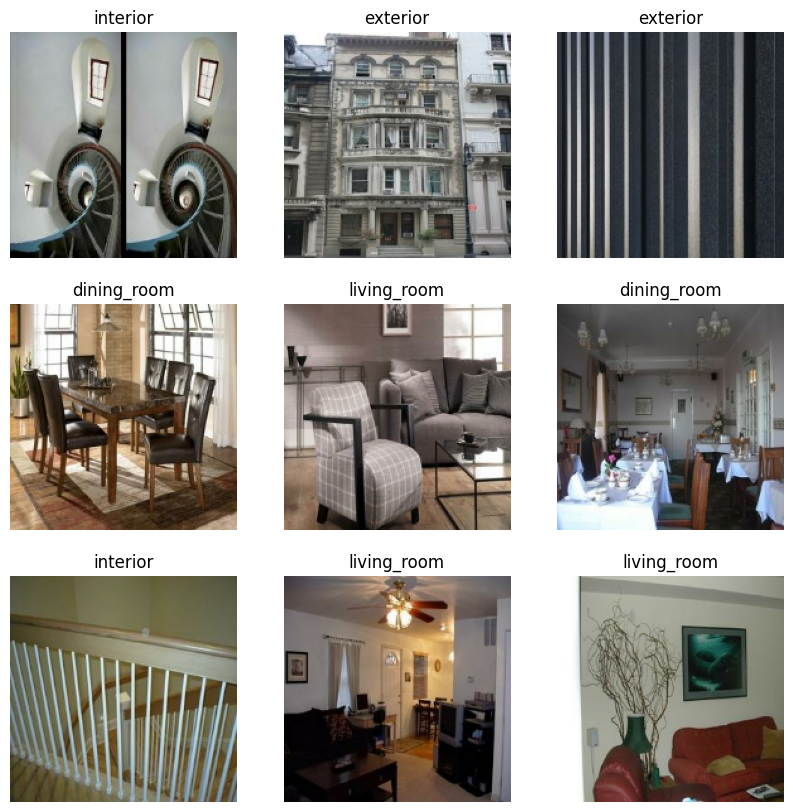

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

# 使用数据增强
当你没有大规模图像数据集时, 通过对训练图像应用随机但真实的变换(例如旋转, 水平翻转和随机缩放), 人为地引入样本多样性是一种良好的做法. 这有助于让模型接触到训练数据的不同方面, 并减少过拟合. 你可以在这篇[教程](https://www.tensorflow.org/tutorials/images/data_augmentation)中了解更多关于数据增强的内容.

In [ ]:
# TODO 2: Add a RandomRotation layer with factor=0.2
# Edit the code by replacing the underscore
data_augmentation = tf.keras.Sequential([
  tf.keras.layers.RandomFlip('horizontal'),
  __________________________,
  tf.keras.layers.RandomZoom(height_factor=0.2, width_factor=0.2)
])

让我们对同一张图像反复应用这些层, 并查看结果.

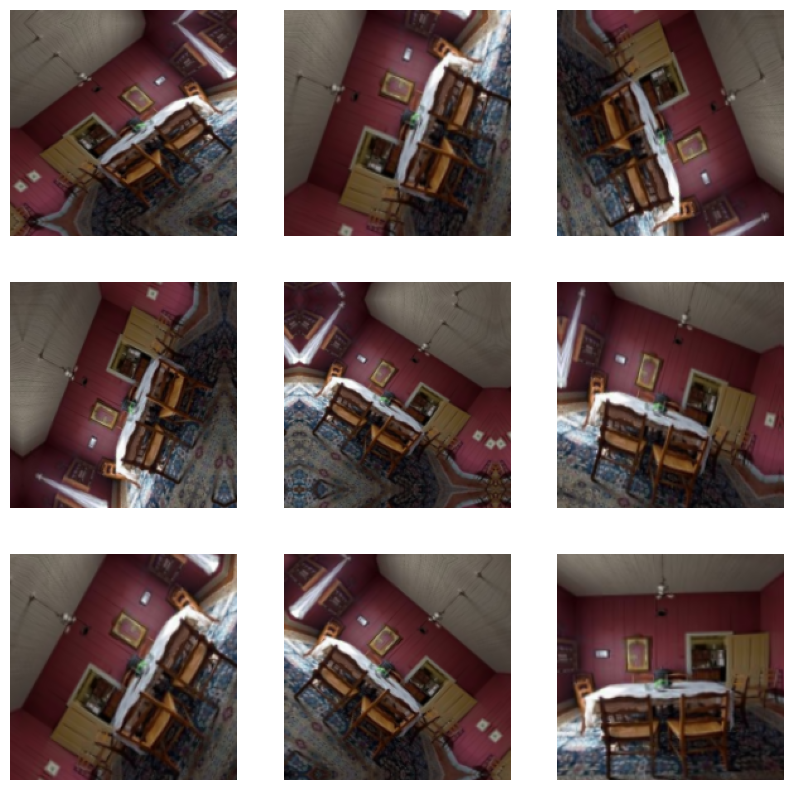

In [ ]:
for image, _ in train_ds.take(1):
  plt.figure(figsize=(10, 10))
  first_image = image[0]
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    augmented_image = data_augmentation(tf.expand_dims(first_image, 0))
    plt.imshow(augmented_image[0] / 255)
    plt.axis('off')

你可以添加更多的数据增强层, 以获得更泛化, 也更准确的模型

In [ ]:
# TODO: Tech Focue Only
# Add more augmentation layers and see how it improves the model performance.

重新缩放像素值
接下来, 你将下载 tf.keras.applications.InceptionV3 用作基础模型. 该模型期望像素值处于 [-1, 1] 区间, 但目前你的图像像素值处于 [0, 255] 区间. 要重新缩放这些值, 请使用该模型自带的预处理方法.

注意: 我们使用 InceptionV3 作为基础模型, 你需要将其替换为你想在项目中用作基础模型的模型.

In [ ]:
preprocess_input = tf.keras.applications.inception_v3.preprocess_input
rescale = tf.keras.layers.Rescaling(1./127.5, offset=-1)

# 从预训练卷积网络创建基础模型
你将基于 **InceptionV3** 模型创建基础模型. 该模型在 **ImageNet** 数据集上进行了预训练, 这是一个包含 140 万张图像和 1000 个类别的大规模数据集. **ImageNet** 是一个研究训练数据集, 涵盖了诸如菠萝蜜和注射器等各种各样的类别. 这些基础知识将帮助我们从特定数据集中区分猫和狗.

首先, 你需要选择使用 **InceptionV3** 的哪一层进行特征提取. 最后的分类层(位于"顶部", 因为大多数机器学习模型的示意图都是自下而上绘制的)用处不大. 相反, 你将遵循常见做法, 依赖展平操作之前的最后一层. 这一层被称为"瓶颈层". 与最终的顶层相比, 瓶颈层的特征保留了更强的通用性.

首先, 实例化一个预加载了在 **ImageNet** 上训练权重的 **InceptionV3** 模型. 通过指定 include_top=False 参数, 你将加载一个不包含顶部分类层的网络, 这对特征提取来说是理想的选择.

In [ ]:
image_size = (img_height, img_width)
image_shape = image_size + (3,)
base_model = tf.keras.applications.InceptionV3(
                     include_top=False,
                     weights='imagenet',
                     input_shape=image_shape
                     )

87910968/87910968 [==============================] - 0s 0us/step


如果你想获得更好的性能, 可以尝试其他基础模型. Keras 中可用模型的列表可以在[这里](https://keras.io/api/applications/)找到

In [ ]:
# TODO: Tech Focus only
# Add different base models and compare the model performance

这个特征提取器将每张 160x160x3 的图像转换为一个 5x5x1280 的特征块. 让我们看看它对一批示例图像做了什么:

In [ ]:
image_batch, label_batch = next(iter(train_ds))
feature_batch = base_model(image_batch)
print(feature_batch.shape)

(32, 4, 4, 2048)


## 特征提取
在这一步中, 你将冻结上一步创建的卷积基, 并将其用作特征提取器. 此外, 你还会在其上添加一个分类器, 并训练这个顶层分类器.

### 冻结卷积基
在编译和训练模型之前冻结卷积基非常重要. 冻结(通过设置 layer.trainable = False)可以防止给定层中的权重在训练过程中被更新. InceptionV3 有很多层, 因此将整个模型的可训练标志设置为 False 会冻结所有这些层.




In [ ]:
base_model.trainable = False
base_model.summary()

Model: "inception_v3"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 180, 180, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d (Conv2D)                (None, 89, 89, 32)   864         ['input_1[0][0]']                
                                                                                                  
 batch_normalization (BatchNorm  (None, 89, 89, 32)  96          ['conv2d[0][0]']                 
 alization)                                                                                       
                                                                                       

## 添加分类头
为了从特征块生成预测结果, 使用 tf.keras.layers.GlobalAveragePooling2D 层对 5x5 的空间位置进行平均, 将特征转换为每张图像一个 2048 元素的向量.

In [ ]:
global_average_layer = tf.keras.layers.GlobalAveragePooling2D()
feature_batch_average = global_average_layer(feature_batch)
print(feature_batch_average.shape)

(32, 2048)


你可以在基础层和预测层之间(bext)潜在地添加更多层, 以便更精细地微调模型, 并可能提升准确率

In [ ]:
# TODO: Tech Focus only
# add more layers and see if it improves the model performance

应用一个 tf.keras.layers.Dense 层, 将这些特征转换为每张图像 7 个类别的预测结果. 这里不需要激活函数, 因为该预测结果将被当作 logit, 也就是原始预测值来处理. 正数预测类别 1, 负数预测类别 0.

In [ ]:
prediction_layer = tf.keras.layers.Dense(num_classes)
prediction_batch = prediction_layer(feature_batch_average)
print(prediction_batch.shape)

(32, 7)


# 构建并编译模型
使用 Keras 函数式 API, 将数据增强, 重新缩放, base_model 和特征提取层串联起来构建模型. 如前所述, 由于我们的模型包含一个 BatchNormalization 层, 所以使用 training=False.


***注意***: 许多模型都包含 tf.keras.layers.BatchNormalization 层. 这一层是一个特殊情况, 在微调的场景下需要格外注意, 本教程后面会展示相关内容.

当你设置 layer.trainable = False 时, BatchNormalization 层会以推理模式运行, 不会更新其均值和方差统计量.

当你为了进行微调而解冻一个包含 BatchNormalization 层的模型时, 应该在调用基础模型时传入 training = False, 使 BatchNormalization 层保持推理模式. 否则, 应用于不可训练权重的更新会破坏模型已经学到的内容.

更多细节请参见[迁移学习指南](https://www.tensorflow.org/guide/keras/transfer_learning).


***注意***: 如果你在前面的步骤中定义了更多的层, 需要在这里把它们加入到要构建和编译的模型层中.

In [ ]:
inputs = tf.keras.Input(shape=(img_height, img_width, 3))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = global_average_layer(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = prediction_layer(x)

# TODO 3: Create the model using tf.keras.Model() function
# Edit the code by replacing the underscore
model = __________

base_learning_rate = 0.0001
model.compile(optimizer=tf.keras.optimizers.legacy.Adam(learning_rate=base_learning_rate),
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 180, 180, 3)]     0         
                                                                 
 sequential (Sequential)     (None, 180, 180, 3)       0         
                                                                 
 tf.math.truediv_1 (TFOpLamb  (None, 180, 180, 3)      0         
 da)                                                             
                                                                 
 tf.math.subtract_1 (TFOpLam  (None, 180, 180, 3)      0         
 bda)                                                            
                                                                 
 inception_v3 (Functional)   (None, 4, 4, 2048)        21802784  
                                                                 
 global_average_pooling2d (G  (None, 2048)             0     

有趣的是可以看看没有经过微调的基础模型表现如何: 如你所见, 结果相当令人失望 :-)

In [ ]:
loss0, accuracy0 = model.evaluate(val_ds)
print("initial loss: {:.2f}".format(loss0))
print("initial accuracy: {:.2f}".format(accuracy0))

44/44 [==============================] - 197s 4s/step - loss: 2.4643 - accuracy: 0.1914
initial loss: 2.46
initial accuracy: 0.19


## 训练模型

现在我们可以开始训练, 也就是对目前作为基础模型的 InceptionV3 进行微调. 我们先从较少的训练轮数(10)开始, 看看最终模型的表现如何.

In [ ]:
early = tf.keras.callbacks.EarlyStopping(patience=10,
                                          min_delta=0.01,
                                          restore_best_weights=True)
initial_epochs = 10

# TODO 4: train the model using the model.fit() function
# Edit the code by replacing the underscore
history = model.fit(train_ds,
                    validation_data=_____,
                    epochs=_____,
                    callbacks=[early])

Epoch 1/10
175/175 [==============================] - 1233s 7s/step - loss: 2.0975 - accuracy: 0.2368 - val_loss: 1.5669 - val_accuracy: 0.4286
Epoch 2/10
175/175 [==============================] - 604s 3s/step - loss: 1.6633 - accuracy: 0.3868 - val_loss: 1.3003 - val_accuracy: 0.5557
Epoch 3/10
175/175 [==============================] - 607s 3s/step - loss: 1.4856 - accuracy: 0.4664 - val_loss: 1.1742 - val_accuracy: 0.6007
Epoch 4/10
175/175 [==============================] - 603s 3s/step - loss: 1.4081 - accuracy: 0.4913 - val_loss: 1.0924 - val_accuracy: 0.6271
Epoch 5/10
175/175 [==============================] - 603s 3s/step - loss: 1.3237 - accuracy: 0.5188 - val_loss: 1.0084 - val_accuracy: 0.6486
Epoch 6/10
175/175 [==============================] - 569s 3s/step - loss: 1.2736 - accuracy: 0.5329 - val_loss: 0.9935 - val_accuracy: 0.6521
Epoch 7/10
175/175 [==============================] - 603s 3s/step - loss: 1.2564 - accuracy: 0.5496 - val_loss: 0.9535 - val_accuracy: 0.658

## 学习曲线(准确率-损失)
让我们看看在使用 InceptionV3 基础模型作为固定特征提取器进行迁移学习时, 训练和验证准确率/损失的学习曲线.

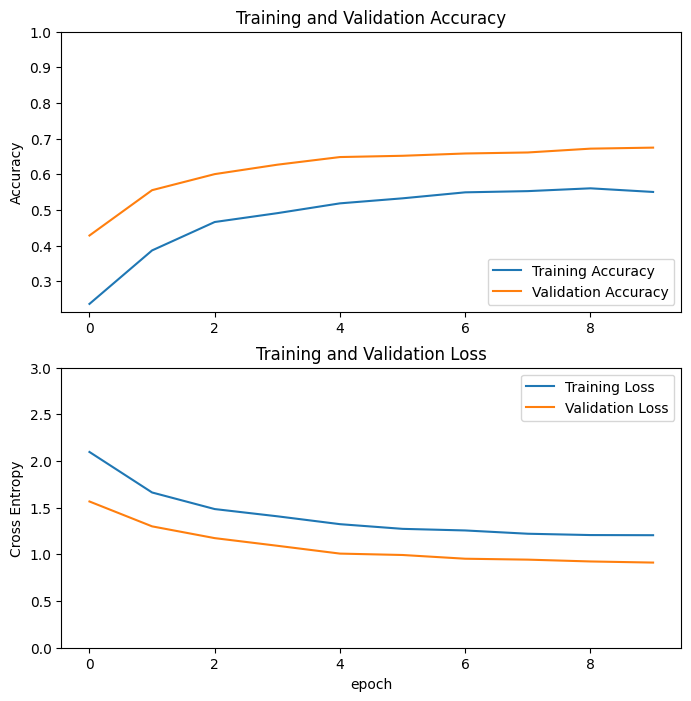

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.ylabel('Accuracy')
plt.ylim([min(plt.ylim()),1])
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.ylabel('Cross Entropy')
plt.ylim([0,3.0])
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()